<a href="https://colab.research.google.com/github/nungggg/Dynamic-SOM/blob/main/Projek/pemodelan_DSOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# GANTI PATH SESUAI FILE KAMU
raw_path = "/content/datamar.xlsx"

df_raw = pd.read_excel(raw_path)

print("Data mentah:", df_raw.shape)
df_raw.head()

Data mentah: (2493, 49)


,No. Pesanan,Status Pesanan,Alasan Pembatalan,Status Pembatalan/ Pengembalian,No. Resi,Opsi Pengiriman,Antar ke counter/ pick-up,Pesanan Harus Dikirimkan Sebelum (Menghindari keterlambatan),Waktu Pengiriman Diatur,Waktu Pesanan Dibuat,...,Perkiraan Ongkos Kirim,Catatan dari Pembeli,Catatan,Username (Pembeli),Nama Penerima,No. Telepon,Alamat Pengiriman,Kota/Kabupaten,Provinsi,Waktu Pesanan Selesai
0,260301W182JHVM,Selesai,NaN,NaN,SPXID060157151463,Hemat Kargo-SPX Hemat,Pickup,2026-03-02 23:59,2026-03-02 21:18,2026-03-01 00:09,...,5.0,NaN,NaN,ni_ndaa_831,s****a,******63,"Harvest City, Jalan Cluster Quince Bloosom Qb1...",KAB. BEKASI,JAWA BARAT,2026-03-06 05:59
1,260301W1G6UG0Y,Selesai,NaN,NaN,SPXID066150383793,Hemat Kargo-SPX Hemat,Pickup,2026-03-02 23:59,2026-03-02 20:50,2026-03-01 00:14,...,5.0,NaN,NaN,irfannurfaiz,D******h,******27,"Jalan Pesing Bendungan, RT.1/RW.5, Kedoya Sela...",KOTA JAKARTA BARAT,DKI JAKARTA,2026-03-06 12:32
2,260301W25W4FSF,Selesai,NaN,NaN,SPXID061183383573,Hemat Kargo-SPX Hemat,Pickup,2026-03-02 23:59,2026-03-02 20:54,2026-03-01 00:26,...,3.5,NaN,NaN,ayuusafitri325,A******i,******13,"Jalan Kh M Romli Tamim, Dusun Jaddih Timur Man...",KAB. BANGKALAN,JAWA TIMUR,2026-03-04 15:56
3,260301061BNFH2,Selesai,NaN,NaN,SPXID066293689603,Reguler (Cashless)-SPX Standard,Pickup,2026-03-02 23:59,2026-03-02 20:56,2026-03-01 02:34,...,8.0,NaN,NaN,sipbuyerid,S******m,******00,"Jalan Peta Selatan No. 48, RT.9/RW.3, Kalideres",KOTA JAKARTA BARAT,DKI JAKARTA,2026-03-10 19:15
4,260301061BNFH2,Selesai,NaN,NaN,SPXID066293689603,Reguler (Cashless)-SPX Standard,Pickup,2026-03-02 23:59,2026-03-02 20:56,2026-03-01 02:34,...,8.0,NaN,NaN,sipbuyerid,S******m,******00,"Jalan Peta Selatan No. 48, RT.9/RW.3, Kalideres",KOTA JAKARTA BARAT,DKI JAKARTA,2026-03-10 19:15


In [ ]:
selected_cols = [
    "Username (Pembeli)",
    "No. Pesanan",
    "Waktu Pesanan Selesai",
    "Nama Produk",
    "Jumlah",
    "Harga Setelah Diskon",
    "Total Pembayaran"
]

df_clean = df_raw[selected_cols].copy()

print("Data setelah cleaning:", df_clean.shape)
df_clean.head()

Data setelah cleaning: (2493, 7)


,Username (Pembeli),No. Pesanan,Waktu Pesanan Selesai,Nama Produk,Jumlah,Harga Setelah Diskon,Total Pembayaran
0,ni_ndaa_831,260301W182JHVM,2026-03-06 05:59,( 1 PACK ISI 24 PCS )HANGTAG IDUL FITRI - TAG ...,1,8.999,10.999
1,irfannurfaiz,260301W1G6UG0Y,2026-03-06 12:32,( 1 PACK ISI 24 PCS )HANGTAG IDUL FITRI - TAG ...,1,8.999,8.970
2,ayuusafitri325,260301W25W4FSF,2026-03-04 15:56,( 1 PACK ISI 24 PCS )HANGTAG IDUL FITRI - TAG ...,1,8.999,10.999
3,sipbuyerid,260301061BNFH2,2026-03-10 19:15,(HARGA 1 PACK ISI 20 PCS) Kartu Ucapan | Greet...,1,7.199,22.398
4,sipbuyerid,260301061BNFH2,2026-03-10 19:15,(HARGA 1 PACK ISI 20 PCS) Kartu Ucapan | Greet...,1,7.199,22.398


In [ ]:
# Hitung transaksi per pelanggan
df_pesanan = df_clean.groupby(
    ["Username (Pembeli)", "No. Pesanan"],
    as_index=False
)["Total Pembayaran"].first()

df_pelanggan = df_pesanan.groupby(
    "Username (Pembeli)"
).agg(
    jumlah_transaksi=("No. Pesanan", "count"),
    total_belanja=("Total Pembayaran", "sum")
).reset_index()

# Gabungkan ke data utama
df_final = df_clean.merge(
    df_pelanggan,
    on="Username (Pembeli)",
    how="left"
)

print("Data final:", df_final.shape)
df_final.head()

Data final: (2493, 9)


,Username (Pembeli),No. Pesanan,Waktu Pesanan Selesai,Nama Produk,Jumlah,Harga Setelah Diskon,Total Pembayaran,jumlah_transaksi,total_belanja
0,ni_ndaa_831,260301W182JHVM,2026-03-06 05:59,( 1 PACK ISI 24 PCS )HANGTAG IDUL FITRI - TAG ...,1,8.999,10.999,1,10.999
1,irfannurfaiz,260301W1G6UG0Y,2026-03-06 12:32,( 1 PACK ISI 24 PCS )HANGTAG IDUL FITRI - TAG ...,1,8.999,8.970,1,8.970
2,ayuusafitri325,260301W25W4FSF,2026-03-04 15:56,( 1 PACK ISI 24 PCS )HANGTAG IDUL FITRI - TAG ...,1,8.999,10.999,1,10.999
3,sipbuyerid,260301061BNFH2,2026-03-10 19:15,(HARGA 1 PACK ISI 20 PCS) Kartu Ucapan | Greet...,1,7.199,22.398,16,442.111
4,sipbuyerid,260301061BNFH2,2026-03-10 19:15,(HARGA 1 PACK ISI 20 PCS) Kartu Ucapan | Greet...,1,7.199,22.398,16,442.111


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_final.copy()

cat_cols = df_encoded.select_dtypes(include="object").columns
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le.classes_

print("Data encoded:", df_encoded.shape)
df_encoded.head()

Data encoded: (2493, 9)


,Username (Pembeli),No. Pesanan,Waktu Pesanan Selesai,Nama Produk,Jumlah,Harga Setelah Diskon,Total Pembayaran,jumlah_transaksi,total_belanja
0,749,89,37,1,1,8.999,10.999,1,10.999
1,517,90,53,1,1,8.999,8.970,1,8.970
2,191,91,7,1,1,8.999,10.999,1,10.999
3,976,0,313,16,1,7.199,22.398,16,442.111
4,976,0,313,16,1,7.199,22.398,16,442.111


In [ ]:
#from google.colab import files

#df_encoded.to_excel("data_encoded.xlsx", index=False)
#files.download("data_encoded.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Identify columns with zero or one unique value
numeric_cols = df_encoded.select_dtypes(include=np.number).columns
zero_variance_cols = [col for col in numeric_cols if df_encoded[col].nunique() <= 1]

if zero_variance_cols:
    print(f"Warning: Columns with zero or one unique value found and will be dropped before scaling: {zero_variance_cols}")
    X_filtered = df_encoded.drop(columns=zero_variance_cols).values.astype(float)
else:
    X_filtered = df_encoded.values.astype(float)

X = X_filtered # Assign to X for consistency

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X) # Use X_filtered for scaling

print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (2493, 9)


In [ ]:
class DynamicSOM:
    def __init__(self, x, y, input_len, elasticity=1.0, random_seed=42):
        np.random.seed(random_seed)
        self.x = x
        self.y = y
        self.input_len = input_len
        self.elasticity = float(elasticity)
        self.weights = np.random.rand(x, y, input_len)

    def winner(self, x):
        d = np.linalg.norm(self.weights - x, axis=2)
        return np.unravel_index(np.argmin(d), (self.x, self.y))

    def train_random(self, data, num_iteration=1000, verbose=True):
        data = np.asarray(data, dtype=float)

        for it in range(num_iteration):
            sample = data[np.random.randint(0, data.shape[0])]
            bmu_x, bmu_y = self.winner(sample)

            for i in range(self.x):
                for j in range(self.y):
                    dist = np.sqrt((i - bmu_x)**2 + (j - bmu_y)**2)
                    h = np.exp(-(dist**2) / (2 * self.elasticity**2))
                    self.weights[i, j] += h * (sample - self.weights[i, j])

            if verbose and it % 100 == 0:
                print(f"Iterasi {it}/{num_iteration}")

    def quantization_error(self, data):
        data = np.asarray(data, dtype=float)
        return np.mean([
            np.linalg.norm(x - self.weights[self.winner(x)])
            for x in data
        ])

Iterasi 0/800
Iterasi 100/800
Iterasi 200/800
Iterasi 300/800
Iterasi 400/800
Iterasi 500/800
Iterasi 600/800
Iterasi 700/800
Quantization Error: 0.17666148661376235
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10


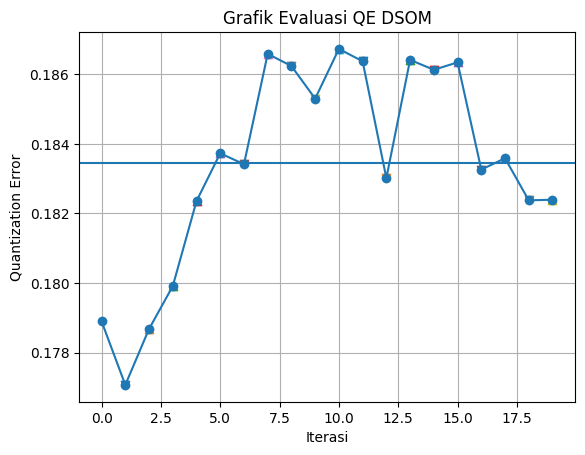

In [ ]:
import matplotlib.pyplot as plt

dsom = DynamicSOM(
    x=20,
    y=20,
    input_len=X_scaled.shape[1],
    elasticity=1.0,
    random_seed=42
)

dsom.train_random(X_scaled, num_iteration=800, verbose=True)

qe = dsom.quantization_error(X_scaled)
print("Quantization Error:", qe)

qe_values = []
iterations = 20

for i in range(iterations):
    dsom.train_random(X_scaled, num_iteration=10)
    qe_values.append(dsom.quantization_error(X_scaled))

# ===== TAMBAHAN DIAGRAM BATANG =====
plt.figure()

plt.plot(qe_values, marker='o')

# tandai titik naik & turun
for i in range(1, len(qe_values)):
    if qe_values[i] < qe_values[i-1]:
        plt.scatter(i, qe_values[i], marker='v')  # turun
    elif qe_values[i] > qe_values[i-1]:
        plt.scatter(i, qe_values[i], marker='^')  # naik

# garis bantu (grid lebih jelas)
plt.grid()

# garis horizontal rata-rata (biar ada acuan)
avg_qe = sum(qe_values) / len(qe_values)
plt.axhline(avg_qe)

plt.title("Grafik Evaluasi QE DSOM")
plt.xlabel("Iterasi")
plt.ylabel("Quantization Error")

plt.show()

Iterasi 0/800
Iterasi 100/800
Iterasi 200/800
Iterasi 300/800
Iterasi 400/800
Iterasi 500/800
Iterasi 600/800
Iterasi 700/800
Quantization Error Awal: 0.17666148661376235
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10
Iterasi 0/10

=== TABEL EVALUASI ===
    Iterasi        QE  Accuracy  Precision    Recall  F1_Score
0         1  0.178904  0.923385   0.881264  0.743736  0.800475
1         2  0.177077  0.922984   0.885017  0.729971  0.791827
2         3  0.178684  0.920176   0.904901  0.715417  0.787699
3         4  0.179913  0.912956   0.895612  0.694917  0.769262
4         5  0.182355  0.912956   0.892135  0.683384  0.759065
5         6  0.183729  0.916968   0.893044  0.711139  0.780420
6         7  0.183415  0.917770   0.873683  0.746870  0.800085
7         8  0.186585  0.922583   0.87407

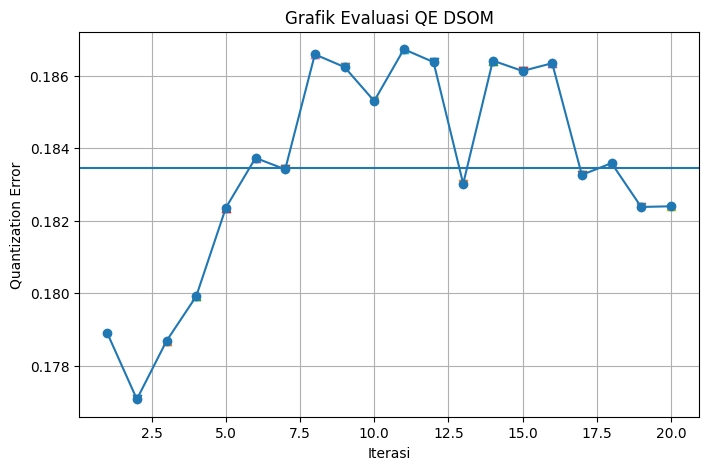

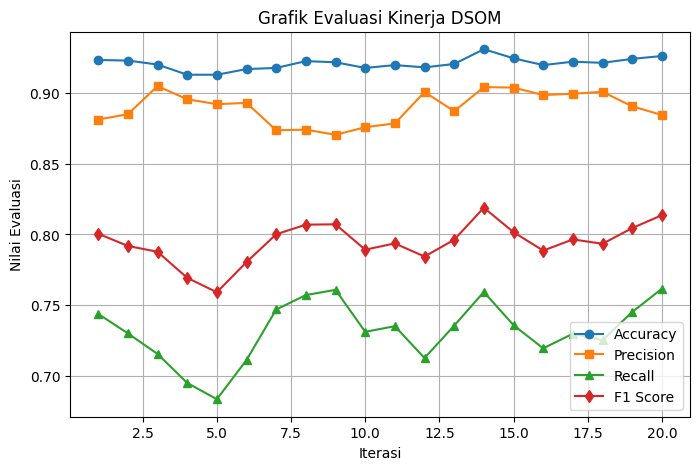

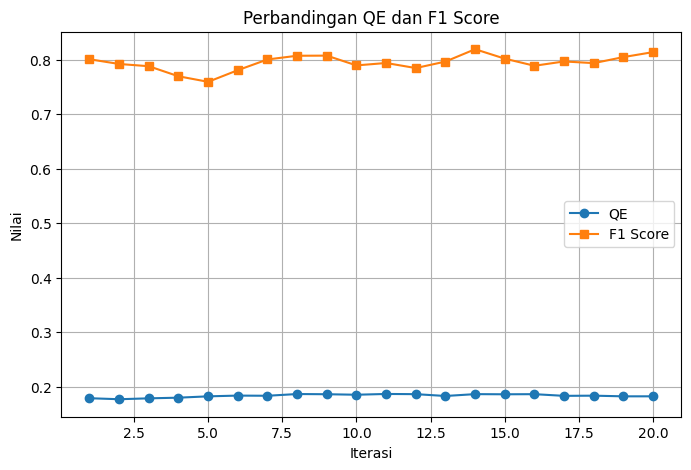

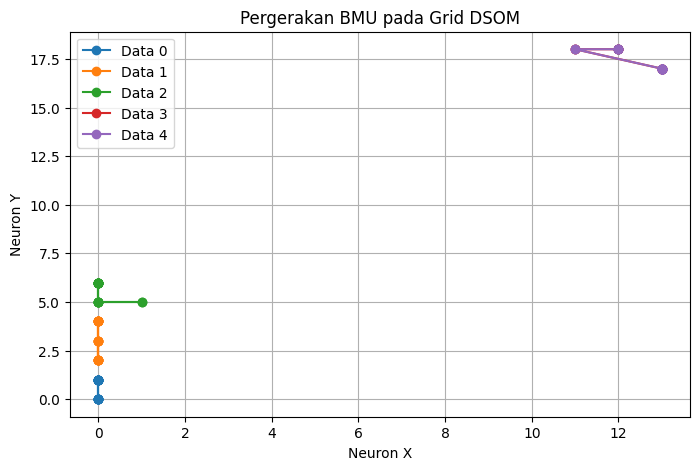

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =============================
# SETUP DSOM
# =============================
dsom = DynamicSOM(
    x=20,
    y=20,
    input_len=X_scaled.shape[1],
    elasticity=1.0,
    random_seed=42
)

# Training awal seperti kode sebelumnya
dsom.train_random(X_scaled, num_iteration=800, verbose=True)

qe_awal = dsom.quantization_error(X_scaled)
print("Quantization Error Awal:", qe_awal)

# =============================
# SETUP EVALUASI
# =============================
iterations = 20
train_per_iterasi = 10
sample_index = [0, 1, 2, 3, 4]  # 5 data untuk tracking BMU

hasil_evaluasi = []
tracking_bmu = []

# Pastikan df_encoded dan X_scaled memiliki jumlah data yang sama
df_hasil = df_encoded.copy().reset_index(drop=True)

if len(df_hasil) != len(X_scaled):
    raise ValueError("Jumlah baris df_encoded dan X_scaled tidak sama. Cek kembali proses preprocessing.")

# =============================
# MEMBUAT LABEL KELAS PELANGGAN
# =============================
def kelas_pelanggan(jumlah):
    if jumlah == 1:
        return "Silver"
    elif jumlah == 2:
        return "Gold"
    else:
        return "Platinum"

df_hasil["kelas_pelanggan"] = df_hasil["jumlah_transaksi"].apply(kelas_pelanggan)

# =============================
# LOOP TRAINING + EVALUASI
# =============================
for i in range(iterations):

    # Training lanjutan 10 iterasi setiap tahap evaluasi
    dsom.train_random(X_scaled, num_iteration=train_per_iterasi)

    # ===== QE =====
    qe = dsom.quantization_error(X_scaled)

    # ===== BMU =====
    bmu = [dsom.winner(x) for x in X_scaled]
    df_hasil["bmu"] = list(map(tuple, bmu))

    # ===== TRACKING BMU UNTUK 5 DATA =====
    row_tracking = {"Iterasi": i + 1}
    for idx in sample_index:
        row_tracking[f"Data_{idx}"] = tuple(bmu[idx])
    tracking_bmu.append(row_tracking)

    # ===== MAPPING BMU KE LABEL MAYORITAS =====
    bmu_map = {}

    for bmu_val, group in df_hasil.groupby("bmu"):
        mayoritas = Counter(group["kelas_pelanggan"]).most_common(1)[0][0]
        bmu_map[bmu_val] = mayoritas

    df_hasil["prediksi"] = df_hasil["bmu"].map(bmu_map)

    # ===== METRIK EVALUASI =====
    y_true = df_hasil["kelas_pelanggan"]
    y_pred = df_hasil["prediksi"]

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    hasil_evaluasi.append({
        "Iterasi": i + 1,
        "QE": qe,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    })

# =============================
# DATAFRAME HASIL
# =============================
df_eval = pd.DataFrame(hasil_evaluasi)
df_tracking = pd.DataFrame(tracking_bmu)

# =============================
# OUTPUT TABEL
# =============================
print("\n=== TABEL EVALUASI ===")
print(df_eval)

print("\n=== TRACKING BMU 5 DATA ===")
print(df_tracking)

# =============================
# GRAFIK EVALUASI QE DSOM
# =============================
plt.figure(figsize=(8, 5))

plt.plot(df_eval["Iterasi"], df_eval["QE"], marker="o")

# Tandai titik naik dan turun
for i in range(1, len(df_eval)):
    if df_eval["QE"].iloc[i] < df_eval["QE"].iloc[i - 1]:
        plt.scatter(df_eval["Iterasi"].iloc[i], df_eval["QE"].iloc[i], marker="v", label="Turun" if i == 1 else "")
    elif df_eval["QE"].iloc[i] > df_eval["QE"].iloc[i - 1]:
        plt.scatter(df_eval["Iterasi"].iloc[i], df_eval["QE"].iloc[i], marker="^", label="Naik" if i == 1 else "")

# Garis horizontal rata-rata QE
avg_qe = df_eval["QE"].mean()
plt.axhline(avg_qe)

plt.title("Grafik Evaluasi QE DSOM")
plt.xlabel("Iterasi")
plt.ylabel("Quantization Error")
plt.grid()
plt.show()

# =============================
# GRAFIK ACCURACY, PRECISION, RECALL, F1-SCORE
# =============================
plt.figure(figsize=(8, 5))

plt.plot(df_eval["Iterasi"], df_eval["Accuracy"], marker="o", label="Accuracy")
plt.plot(df_eval["Iterasi"], df_eval["Precision"], marker="s", label="Precision")
plt.plot(df_eval["Iterasi"], df_eval["Recall"], marker="^", label="Recall")
plt.plot(df_eval["Iterasi"], df_eval["F1_Score"], marker="d", label="F1 Score")

plt.title("Grafik Evaluasi Kinerja DSOM")
plt.xlabel("Iterasi")
plt.ylabel("Nilai Evaluasi")
plt.legend()
plt.grid()
plt.show()

# =============================
# GRAFIK PERBANDINGAN QE DAN F1-SCORE
# =============================
plt.figure(figsize=(8, 5))

plt.plot(df_eval["Iterasi"], df_eval["QE"], marker="o", label="QE")
plt.plot(df_eval["Iterasi"], df_eval["F1_Score"], marker="s", label="F1 Score")

plt.title("Perbandingan QE dan F1 Score")
plt.xlabel("Iterasi")
plt.ylabel("Nilai")
plt.legend()
plt.grid()
plt.show()

# =============================
# GRAFIK PERGERAKAN BMU
# =============================
plt.figure(figsize=(8, 5))

for idx in sample_index:
    x_coords = [pos[0] for pos in df_tracking[f"Data_{idx}"]]
    y_coords = [pos[1] for pos in df_tracking[f"Data_{idx}"]]

    plt.plot(x_coords, y_coords, marker="o", label=f"Data {idx}")

plt.title("Pergerakan BMU pada Grid DSOM")
plt.xlabel("Neuron X")
plt.ylabel("Neuron Y")
plt.legend()
plt.grid()
plt.show()

In [ ]:
bmu = [dsom.winner(x) for x in X_scaled]

df_hasil = df_encoded.copy()
df_hasil["cluster_x"] = [i for i, j in bmu]
df_hasil["cluster_y"] = [j for i, j in bmu]

df_hasil.head()

,Username (Pembeli),No. Pesanan,Waktu Pesanan Selesai,Nama Produk,Jumlah,Harga Setelah Diskon,Total Pembayaran,jumlah_transaksi,total_belanja,cluster_x,cluster_y
0,749,89,37,1,1,8.999,10.999,1,10.999,0,0
1,517,90,53,1,1,8.999,8.970,1,8.970,0,2
2,191,91,7,1,1,8.999,10.999,1,10.999,0,5
3,976,0,313,16,1,7.199,22.398,16,442.111,12,18
4,976,0,313,16,1,7.199,22.398,16,442.111,12,18


In [ ]:
print("Iterasi:", i+1)
print("Contoh BMU:", bmu[:5])

Iterasi: 20
Contoh BMU: [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(5)), (np.int64(12), np.int64(18)), (np.int64(12), np.int64(18))]


In [ ]:
def kelas_pelanggan(jumlah):
    if jumlah == 1:
        return "Silver"
    elif jumlah == 2:
        return "Gold"
    else:
        return "Platinum"

df_hasil["kelas_pelanggan"] = df_hasil["jumlah_transaksi"].apply(kelas_pelanggan)

df_hasil["kelas_pelanggan"].value_counts()

,count
kelas_pelanggan,
Silver,2113
Gold,279
Platinum,101


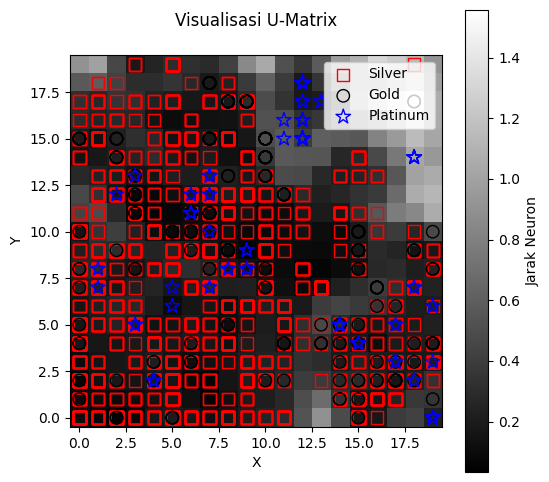

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# HITUNG U-MATRIX
# ===============================
weights = dsom.weights
x, y, _ = weights.shape
u_matrix = np.zeros((x, y))

for i in range(x):
    for j in range(y):
        neighbors = []
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            ni, nj = i + dx, j + dy
            if 0 <= ni < x and 0 <= nj < y:
                neighbors.append(
                    np.linalg.norm(weights[i, j] - weights[ni, nj])
                )
        u_matrix[i, j] = np.mean(neighbors) if neighbors else 0

# ===============================
# VISUALISASI DSOM 2D
# ===============================
plt.figure(figsize=(6, 6))

# Background U-Matrix
plt.imshow(
    u_matrix.T,
    cmap="gray",
    origin="lower"
)
plt.colorbar(label="Jarak Neuron")

# Plot titik pelanggan berdasarkan kelas
kelas_config = {
    "Silver":   {"marker": "s", "edge": "red",   "size": 80},
    "Gold":     {"marker": "o", "edge": "black", "size": 80},
    "Platinum": {"marker": "*", "edge": "blue",  "size": 120},
}

for kelas, cfg in kelas_config.items():
    subset = df_hasil[df_hasil["kelas_pelanggan"] == kelas]
    plt.scatter(
        subset["cluster_x"],
        subset["cluster_y"],
        marker=cfg["marker"],
        facecolors="none",
        edgecolors=cfg["edge"],
        s=cfg["size"],
        label=kelas
    )

# Judul & Axis
plt.title(
    "Visualisasi U-Matrix\n"
)
plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.grid(False)
plt.show()

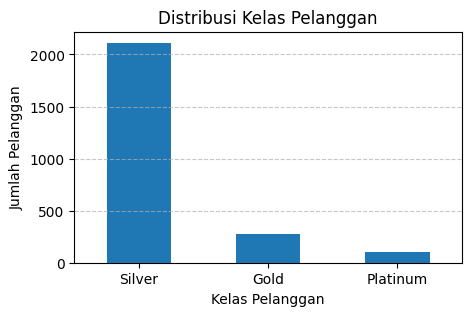

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap kelas
kelas_counts = df_hasil["kelas_pelanggan"].value_counts()

# Plot
plt.figure(figsize=(5, 3))
kelas_counts.plot(kind="bar")

plt.title("Distribusi Kelas Pelanggan")
plt.xlabel("Kelas Pelanggan")
plt.ylabel("Jumlah Pelanggan")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

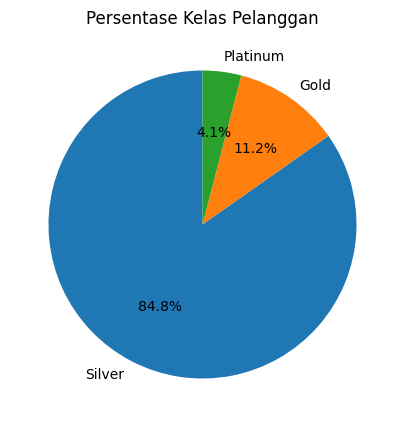

In [ ]:
plt.figure(figsize=(5, 5))
kelas_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Persentase Kelas Pelanggan")
plt.show()